# Emotion Classification with DistilBERT

## Setup

In [6]:
from datasets import load_dataset

# Load the multilingual dataset
raw_datasets = load_dataset("Sukuna404/emotion-multilingual")
print(raw_datasets)

DatasetDict({
    train: Dataset({
        features: ['text', 'label', 'lang'],
        num_rows: 80000
    })
    validation: Dataset({
        features: ['text', 'label', 'lang'],
        num_rows: 10000
    })
    test: Dataset({
        features: ['text', 'label', 'lang'],
        num_rows: 10000
    })
})


## Data Loading

This cell loads the emotion dataset from Hugging Face datasets. It defines the base URL and specific file paths for the train, validation, and test splits, then loads them as a `DatasetDict`.

In [7]:
import pandas as pd

# Convert to Pandas DataFrame for analysis
train_df = pd.DataFrame(raw_datasets["train"])



## Initial Data Exploration

This section begins with converting the raw Hugging Face `Dataset` object for the training set into a Pandas DataFrame for easier exploratory data analysis (EDA).

In [8]:
print(train_df.isnull().sum())


text     0
label    0
lang     0
dtype: int64


In [9]:
# 3. Check class distribution
# The dataset typically uses standard emotion IDs. Let's inspect the features to map them correctly.
labels = raw_datasets["train"].features["label"].names
id2label = {i: label for i, label in enumerate(labels)}
label2id = {label: i for i, label in enumerate(labels)}

train_df['emotion_name'] = train_df['label'].map(id2label)
print(f"Labels: {id2label}")
print(train_df['emotion_name'].value_counts())

Labels: {0: 'sadness', 1: 'joy', 2: 'love', 3: 'anger', 4: 'fear', 5: 'surprise'}
emotion_name
joy         26810
sadness     23330
anger       10795
fear         9685
love         6520
surprise     2860
Name: count, dtype: int64


### Analyze Text Length Distribution

This cell calculates the word count for each text entry in the training set and provides descriptive statistics. This information is useful for determining an appropriate `max_length` parameter for the tokenizer, ensuring that most texts are captured without excessive padding or truncation.

In [10]:
# 4. Check text length distribution (To help choose your max_length parameter)
train_df['word_count'] = train_df['text'].apply(lambda x: len(x.split()))
print(train_df['word_count'].describe())

count    80000.000000
mean        18.315300
std         10.718482
min          1.000000
25%         10.000000
50%         16.000000
75%         24.000000
max        126.000000
Name: word_count, dtype: float64


## Model and Tokenizer Setup

This section prepares the environment for training a Hugging Face Transformers model. It installs necessary libraries and imports key modules like `AutoTokenizer`, `AutoModelForSequenceClassification`, `TrainingArguments`, and `Trainer`.

In [11]:
# Install and import all necessary libraries first
!pip install -q transformers[torch] evaluate accelerate

import torch
import numpy as np
import pandas as pd
import evaluate
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    pipeline
)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 4.8 MB/s eta 0:00:00


### Map Labels to IDs

This cell creates a reverse mapping from emotion names back to their numerical IDs (`label2id`), which is required by the Hugging Face model for classification.

In [12]:
label2id = {v: k for k, v in id2label.items()}
label2id

{'sadness': 0, 'joy': 1, 'love': 2, 'anger': 3, 'fear': 4, 'surprise': 5}

### Initialize Tokenizer

Here, the `AutoTokenizer` is loaded with the `distilbert-base-uncased` pre-trained model. The tokenizer is responsible for converting raw text into numerical input IDs that the model can understand.

In [13]:
# Use the multilingual version of DistilBERT
model_ckpt = "distilbert-base-multilingual-cased"
tokenizer = AutoTokenizer.from_pretrained(model_ckpt)

config.json:   0%|          | 0.00/466 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/996k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.96M [00:00<?, ?B/s]

### Define Tokenization Function

This function defines how each batch of text data will be processed by the tokenizer. It truncates sequences longer than `max_length` (set to 66 based on EDA) and will handle dynamic padding during batching.

In [14]:
def tokenize_function(batch):
    # Truncate anything over 66 words; pad sequences dynamically within batches
    return tokenizer(batch["text"], truncation=True, max_length=66)

In [15]:
print("Converting text sequences into input tensors...")
tokenized_datasets = raw_datasets.map(tokenize_function, batched=True)

Converting text sequences into input tensors...


Map:   0%|          | 0/80000 [00:00<?, ? examples/s]

Map:   0%|          | 0/10000 [00:00<?, ? examples/s]

Map:   0%|          | 0/10000 [00:00<?, ? examples/s]

In [16]:
tokenized_datasets

DatasetDict({
    train: Dataset({
        features: ['text', 'label', 'lang', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 80000
    })
    validation: Dataset({
        features: ['text', 'label', 'lang', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 10000
    })
    test: Dataset({
        features: ['text', 'label', 'lang', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 10000
    })
})

## Model Initialization and Metrics



This section initializes the `AutoModelForSequenceClassification` with the pre-trained `distilbert-base-uncased` weights, configuring it for a 6-class emotion classification task. It also loads evaluation metrics (accuracy and F1-macro) and defines a `compute_metrics` function for evaluating model performance during training.

In [17]:
print(f"Initializing Multilingual DistilBERT for {len(id2label)} classes...")
model = AutoModelForSequenceClassification.from_pretrained(
    "distilbert-base-multilingual-cased",
    num_labels=len(id2label),
    id2label=id2label,
    label2id=label2id
)

accuracy_metric = evaluate.load("accuracy")
f1_metric = evaluate.load("f1")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    acc = accuracy_metric.compute(predictions=predictions, references=labels)["accuracy"]
    f1 = f1_metric.compute(predictions=predictions, references=labels, average="macro")["f1"]
    return {"accuracy": acc, "f1_macro": f1}

Initializing Multilingual DistilBERT for 6 classes...


model.safetensors:   0%|          | 0.00/542M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-multilingual-cased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


## Model Training

This cell configures the `TrainingArguments` for the `Trainer`, specifying parameters like learning rate, batch size, number of epochs, and evaluation strategy. It then initializes the `Trainer` and starts the training process. After training, the best model is saved to disk.

In [18]:
training_args = TrainingArguments(
    output_dir="./distilbert-emotion-classifier",
    learning_rate=2e-5,                  # Small LR protects pre-trained linguistic knowledge
    per_device_train_batch_size=16,       # Optimal batch sizing for a standard Colab T4 GPU
    per_device_eval_batch_size=16,
    num_train_epochs=8,                  # Sufficient iterations for small text classification datasets
    weight_decay=0.01,                    # L2 Regularization penalty
    eval_strategy="epoch",          # Check validation performance at the end of every epoch
    save_strategy="epoch",               # Save model checkpoints chronologically per epoch
    logging_steps=100,
    load_best_model_at_end=True,         # Roll back model to the epoch with the highest score
    metric_for_best_model="f1_macro",    # Optimization tracking objective
    fp16=torch.cuda.is_available(),      # Mixed-precision training drops memory usage & doubles speed
    report_to="none"                     # Mutes background third-party logging integrations
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_datasets["train"],
    eval_dataset=tokenized_datasets["validation"],
    processing_class=tokenizer,
    compute_metrics=compute_metrics,
)

print("Beginning model training execution...")
trainer.train()

# Permanently persist training results to disk
trainer.save_model("./final_emotion_model")
print("Model artifacts successfully saved.")

Beginning model training execution...


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro
1,0.526389,0.483801,0.827600,0.788474
2,0.363823,0.437265,0.846600,0.812038
3,0.286933,0.440856,0.848800,0.817901
4,0.243575,0.488344,0.853000,0.815229
5,0.193777,0.571070,0.851600,0.817671
6,0.122506,0.654086,0.851600,0.816701
7,0.142046,0.746480,0.854300,0.822601
8,0.077699,0.814909,0.853400,0.821264


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model artifacts successfully saved.


## Visualization and Final Evaluation

This section visualizes the training and validation loss, along with the validation accuracy and F1-macro scores over epochs. It also performs a final evaluation of the trained model on the unseen test set to assess its generalization capability.

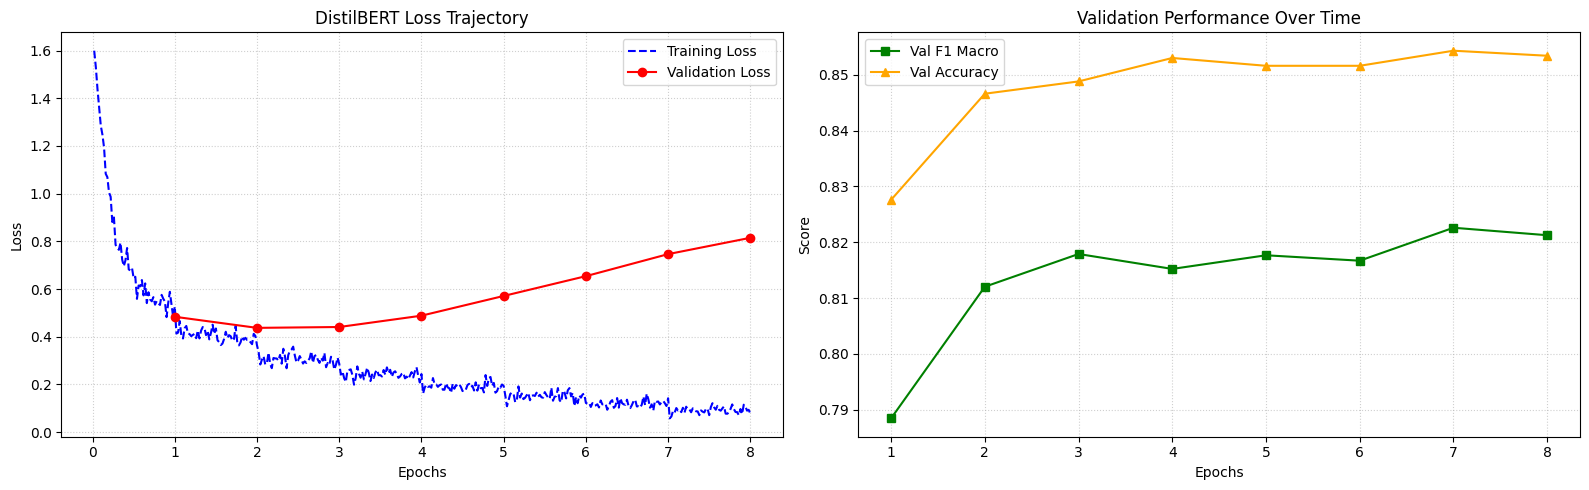


=== Running Final Evaluation on the Test Set ===


Test Loss:     0.7826
Test Accuracy: 0.8428
Test F1 Macro: 0.7919


In [19]:
import matplotlib.pyplot as plt
import pandas as pd

# ==============================================================================
# 1. GENERATE LOSS & METRIC CURVES
# ==============================================================================
history = trainer.state.log_history
df_logs = pd.DataFrame(history)

# Isolate training logs from evaluation checkpoints
df_train = df_logs[df_logs['loss'].notna()]
df_eval = df_logs[df_logs['eval_loss'].notna()]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

# Plot 1: Loss curves
ax1.plot(df_train['epoch'], df_train['loss'], label='Training Loss', color='blue', linestyle='--')
ax1.plot(df_eval['epoch'], df_eval['eval_loss'], label='Validation Loss', color='red', marker='o')
ax1.set_title('DistilBERT Loss Trajectory')
ax1.set_xlabel('Epochs')
ax1.set_ylabel('Loss')
ax1.grid(True, linestyle=':', alpha=0.6)
ax1.legend()

# Plot 2: Macro F1 and Accuracy
if 'eval_f1_macro' in df_eval.columns:
    ax2.plot(df_eval['epoch'], df_eval['eval_f1_macro'], label='Val F1 Macro', color='green', marker='s')
if 'eval_accuracy' in df_eval.columns:
    ax2.plot(df_eval['epoch'], df_eval['eval_accuracy'], label='Val Accuracy', color='orange', marker='^')
ax2.set_title('Validation Performance Over Time')
ax2.set_xlabel('Epochs')
ax2.set_ylabel('Score')
ax2.grid(True, linestyle=':', alpha=0.6)
ax2.legend()

plt.tight_layout()
plt.show()

# ==============================================================================
# 2. EVALUATE ON THE TEST SET
# ==============================================================================
print("\n=== Running Final Evaluation on the Test Set ===")
test_results = trainer.evaluate(eval_dataset=tokenized_datasets["test"])

print(f"Test Loss:     {test_results['eval_loss']:.4f}")
print(f"Test Accuracy: {test_results['eval_accuracy']:.4f}")
print(f"Test F1 Macro: {test_results['eval_f1_macro']:.4f}")

In [20]:
print("Testing multilingual out-of-sample predictions...")
classifier = pipeline(
    "text-classification",
    model="./final_emotion_model",
    device=0 if torch.cuda.is_available() else -1
)

# Testing with various languages (English, French, Spanish, German, etc.)
sample_prompts = [
    "I am so happy today!", # English
    "Je suis très en colère contre ce service.", # French (Anger)
    "Estoy muy asustado por lo que pasó.", # Spanish (Fear)
    "Es ist eine große Überraschung für mich!", # German (Surprise)
    "Mi sento molto triste per questa notizia." # Italian (Sadness)
]

for text in sample_prompts:
    res = classifier(text)[0]
    print(f"\nInput: \"{text}\" -> {res['label']} ({res['score']:.4f})")

Testing multilingual out-of-sample predictions...


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]


Input: "I am so happy today!" -> joy (1.0000)

Input: "Je suis très en colère contre ce service." -> anger (0.9994)

Input: "Estoy muy asustado por lo que pasó." -> fear (0.9996)

Input: "Es ist eine große Überraschung für mich!" -> joy (0.6356)

Input: "Mi sento molto triste per questa notizia." -> sadness (0.9992)
